In [28]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [10]:
from pathlib import Path

ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"

print(ROOT)
print(DATA_RAW)

/Users/sidmohandidir/predictai-industrial
/Users/sidmohandidir/predictai-industrial/data/raw


In [11]:
df_raw = pd.read_csv(DATA_RAW / "train_FD001.txt", sep='\s+', header=None)
print(df_raw.head())
print(f"\nDimensions : {df_raw.shape}")

   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
2  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
3  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
4  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   

        25  
0  23.4190  
1  23.4236  
2  23.3442  
3  23.3739  
4  23.4044  

[5 rows

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pr/rnq8pcq50sb04bf50400q0nw0000gn/T/ipykernel_91086/1576916878.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_raw = pd.read_csv(DATA_RAW / "train_FD001.txt", sep='\s+', header=None)


In [21]:
COLUMNS = (
    ['unit_id', 'cycle'] +        # identifiants
    ['op_1', 'op_2', 'op_3'] +    # conditions opérationnelles
    [f'sensor_{i}' for i in range (1,22)]  # 21 capteurs
)
df = pd.read_csv(DATA_RAW / "train_FD001.txt", sep=r'\s+', header=None, names=COLUMNS)

In [23]:
print(df.shape)
print(df.head())
print(df.dtypes)

(20631, 26)
   unit_id  cycle    op_1    op_2   op_3  sensor_1  sensor_2  sensor_3  \
0        1      1 -0.0007 -0.0004  100.0    518.67    641.82   1589.70   
1        1      2  0.0019 -0.0003  100.0    518.67    642.15   1591.82   
2        1      3 -0.0043  0.0003  100.0    518.67    642.35   1587.99   
3        1      4  0.0007  0.0000  100.0    518.67    642.35   1582.79   
4        1      5 -0.0019 -0.0002  100.0    518.67    642.37   1582.85   

   sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  \
0   1400.60     14.62  ...     521.66    2388.02    8138.62     8.4195   
1   1403.14     14.62  ...     522.28    2388.07    8131.49     8.4318   
2   1404.20     14.62  ...     522.42    2388.03    8133.23     8.4178   
3   1401.87     14.62  ...     522.86    2388.08    8133.83     8.3682   
4   1406.22     14.62  ...     522.19    2388.04    8133.80     8.4294   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0       0.03        392     

In [24]:
print(f"Number of engines: {df['unit_id'].nunique()}")
print(f"Average cycles per engine: {df.groupby('unit_id')['cycle'].max().mean():.1f}")
print(f"Missing values: {df.isnull().sum().sum()}")

Number of engines: 100
Average cycles per engine: 206.3
Missing values: 0


In [ ]:
# Compute the lifespan of each engine (max cycle = total life before failure)
life_per_engine = df.groupby('unit_id')['cycle'].max()

# Quick statistical summary of engine lifespans
print(life_per_engine.describe())

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


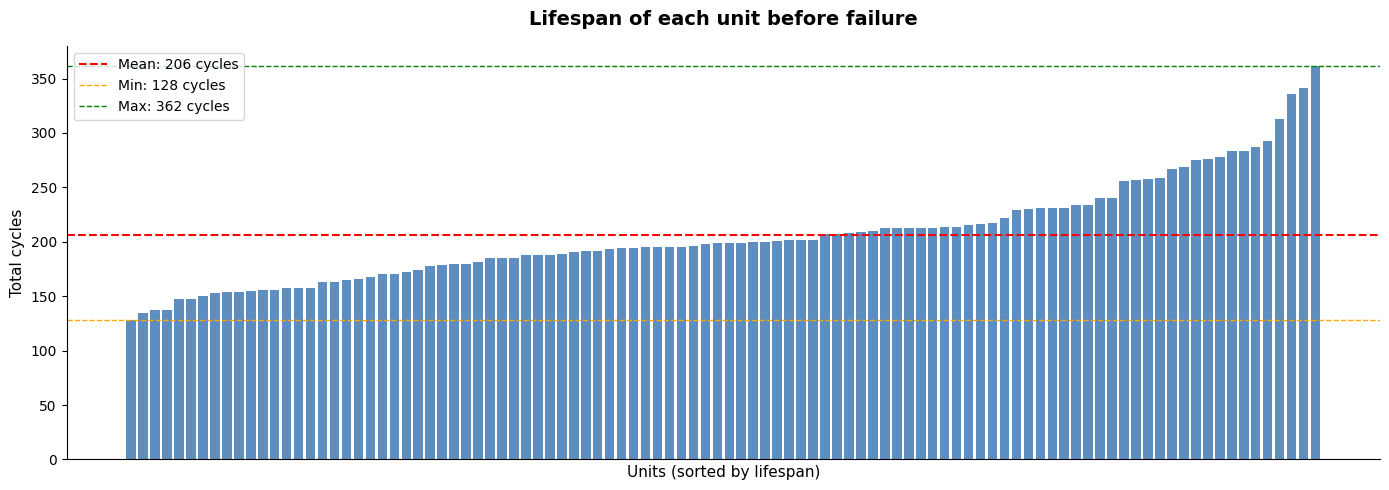

In [30]:
# Visualize the distribution of engine lifespans
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(range(len(life_per_engine.sort_values())), 
       life_per_engine.sort_values().values, 
       color='#185FA5', alpha=0.7, width=0.8)

# Reference lines
ax.axhline(life_per_engine.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {life_per_engine.mean():.0f} cycles')
ax.axhline(life_per_engine.min(), color='orange', linestyle='--', linewidth=1, label=f'Min: {life_per_engine.min():.0f} cycles')
ax.axhline(life_per_engine.max(), color='green', linestyle='--', linewidth=1, label=f'Max: {life_per_engine.max():.0f} cycles')

ax.set_title('Lifespan of each unit before failure', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Units (sorted by lifespan)', fontsize=11)
ax.set_ylabel('Total cycles', fontsize=11)
ax.set_xticks([])  # Remove unreadable labels
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

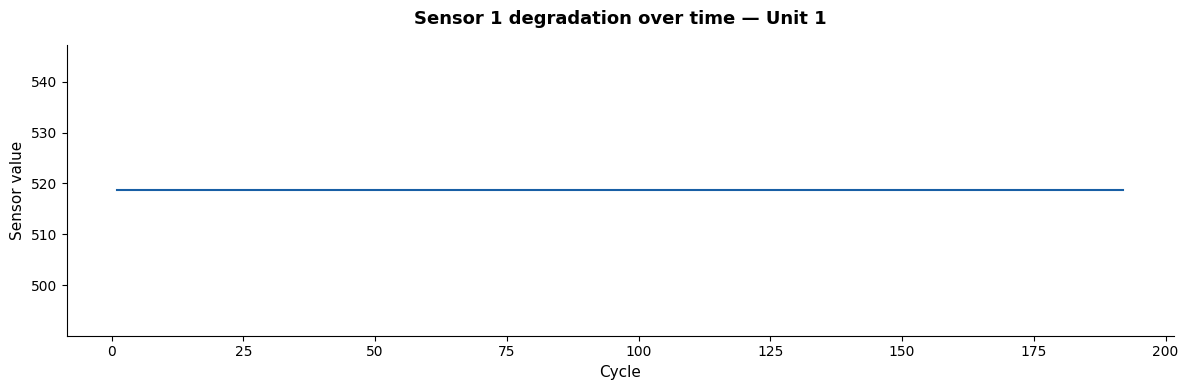

In [33]:
# Select one unit to visualize sensor degradation over time
unit_1 = df[df['unit_id'] == 1]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(unit_1['cycle'], unit_1['sensor_1'], 
        color='#185FA5', linewidth=1.5)

ax.set_title('Sensor 1 degradation over time — Unit 1', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Cycle', fontsize=11)
ax.set_ylabel('Sensor value', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

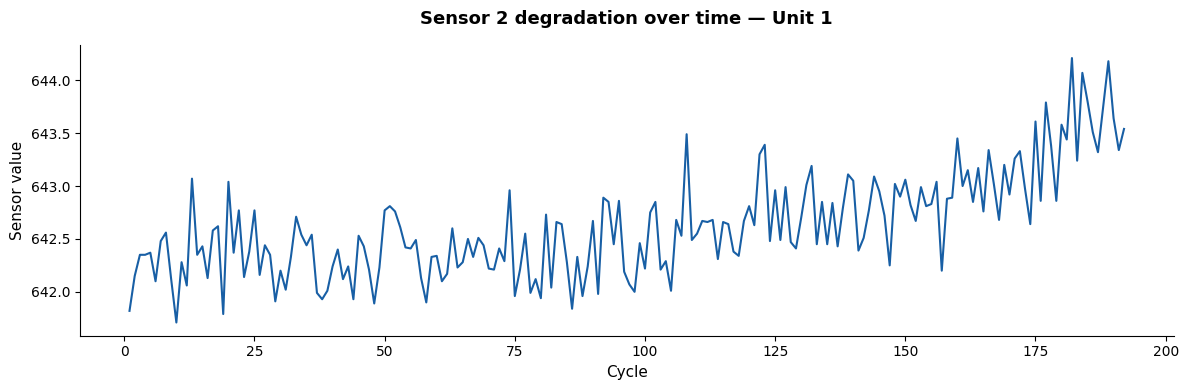

In [34]:
# Select one unit to visualize sensor degradation over time
unit_1 = df[df['unit_id'] == 1]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(unit_1['cycle'], unit_1['sensor_2'], 
        color='#185FA5', linewidth=1.5)

ax.set_title('Sensor 2 degradation over time — Unit 1', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Cycle', fontsize=11)
ax.set_ylabel('Sensor value', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
# Identify constant sensors (variance = 0 means no useful information)
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
variances = df[sensor_cols].var()

constant_sensors = variances[variances < 0.01].index.tolist()
useful_sensors = variances[variances >= 0.01].index.tolist()

print(f"Constant sensors (useless): {constant_sensors}")
print(f"Useful sensors: {useful_sensors}")
print(f"Kept: {len(useful_sensors)} out of 21")

Constant sensors (useless): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']
Kept: 11 out of 21


In [36]:
#feature engineering 
# Useful sensors identified in week 1
useful_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21'
]

print(f"Working with {len(useful_sensors)} sensors")

Working with 11 sensors


In [37]:
# Window size : how many cycles we look back to compute the trend
WINDOW = 10

# Work on a copy to never modify the original data
df_features = df.copy()

# For each useful sensor, compute 3 rolling features
for sensor in useful_sensors:
    
    # Rolling mean — smoothed trend of the sensor
    df_features[f'{sensor}_mean_{WINDOW}'] = (
        df_features.groupby('unit_id')[sensor]
        .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
    )
    
    # Rolling std — instability of the sensor
    df_features[f'{sensor}_std_{WINDOW}'] = (
        df_features.groupby('unit_id')[sensor]
        .transform(lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0))
    )
    
    # Difference with previous cycle — rate of change
    df_features[f'{sensor}_diff'] = (
        df_features.groupby('unit_id')[sensor]
        .transform(lambda x: x.diff().fillna(0))
    )

print(f"Original features : {len(df.columns)}")
print(f"After feature engineering : {len(df_features.columns)}")

Original features : 26
After feature engineering : 59


In [38]:
# Define the final feature set for the ML model
feature_cols = (
    ['cycle', 'op_1', 'op_2', 'op_3'] +
    useful_sensors +
    [f'{s}_mean_{WINDOW}' for s in useful_sensors] +
    [f'{s}_std_{WINDOW}' for s in useful_sensors] +
    [f'{s}_diff' for s in useful_sensors]
)

print(f"Total features for the model : {len(feature_cols)}")

Total features for the model : 48


In [39]:
# Calculate RUL for each engine at each cycle
# RUL = Remaining Useful Life = how many cycles left before failure
max_cycles = df_features.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']

# Merge max cycles back to get RUL per row
df_features = df_features.merge(max_cycles, on='unit_id')
df_features['RUL'] = df_features['max_cycle'] - df_features['cycle']

# Drop helper column — no longer needed
df_features.drop('max_cycle', axis=1, inplace=True)

# X = input features, y = target variable (what the model learns to predict)
X = df_features[feature_cols]
y = df_features['RUL']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"RUL range : {y.min()} to {y.max()}")

X shape : (20631, 48)
y shape : (20631,)
RUL range : 0 to 361


In [40]:
from sklearn.model_selection import train_test_split

# Split data : 80% training, 20% testing
# random_state=42 ensures reproducibility — same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (16504, 48)
Test set     : (4127, 48)


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train a Random Forest to predict RUL
# n_estimators = number of trees in the forest
# random_state = reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate — RMSE is the main metric for RUL prediction
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")

RMSE : 20.05 cycles
MAE  : 13.67 cycles


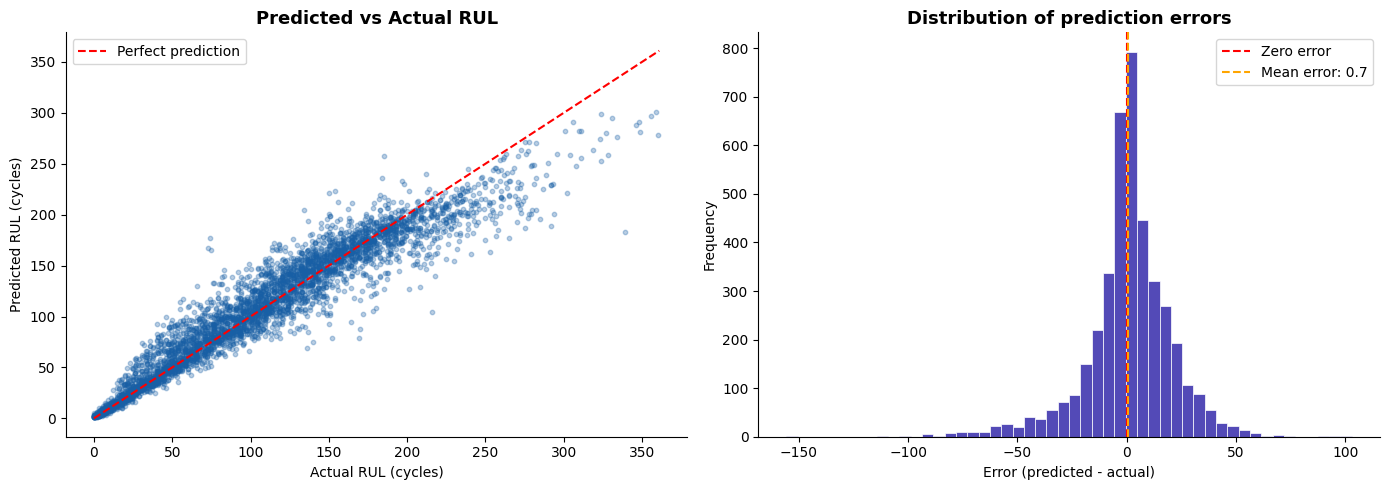

In [42]:
# Visualize model performance : predictions vs actual RUL and error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Each point is one test observation
# Points on the red line = perfect prediction
# Points above = model overestimates RUL (dangerous — thinks machine is healthier than it is)
# Points below = model underestimates RUL (conservative — triggers unnecessary maintenance)
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#185FA5', s=10)
axes[0].plot([0, 361], [0, 361], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual RUL', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2 — Error = predicted - actual
# Centered on 0 = no systematic bias
# Spread = variance of errors (links to RMSE)
# Asymmetry = model systematically over or underestimates
errors = y_pred - y_test
axes[1].hist(errors, bins=50, color='#534AB7', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(errors.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean error: {errors.mean():.1f}')
axes[1].set_title('Distribution of prediction errors', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Error (predicted - actual)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()